In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Using device:", DEVICE)

PyTorch: 2.12.1+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 2050
Using device: cuda


In [2]:


model = models.resnet18(weights=None)

# Same final layer used during training
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(DEVICE)

print("ResNet18 architecture created.")
print("Output classes:", model.fc.out_features)

ResNet18 architecture created.
Output classes: 2


In [3]:

MODEL_PATH = "../models/photo_resnet18_best.pth"

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("========================================")
print("PHOTO MODEL LOADED")
print("========================================")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])
print("Device:", next(model.parameters()).device)

PHOTO MODEL LOADED
Checkpoint epoch: 5
Validation loss: 0.057779437897726896
Validation accuracy: 97.95
Device: cuda:0


In [4]:
# ============================================================
# PHOTO PREPROCESSING
# ============================================================

IMAGE_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image preprocessing ready.")
print("Input size:", IMAGE_SIZE)


Image preprocessing ready.
Input size: 224


In [6]:
from datasets import load_dataset

# CIFAKE provides only a TRAIN split
test_stream = load_dataset(
    "yanbax/CIFAKE_autotrain_compatible",
    split="train",
    streaming=True
)

print("Dataset stream ready.")

Dataset stream ready.


In [8]:
from datasets import load_dataset

test_dataset = load_dataset(
    "dragonintelligence/CIFAKE-image-dataset",
    split="test"
)

print("Test dataset loaded")
print("Test images:", len(test_dataset))
print(test_dataset.features)

Test dataset loaded
Test images: 20000
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['FAKE', 'REAL'])}


Label: 0
Label name: FAKE


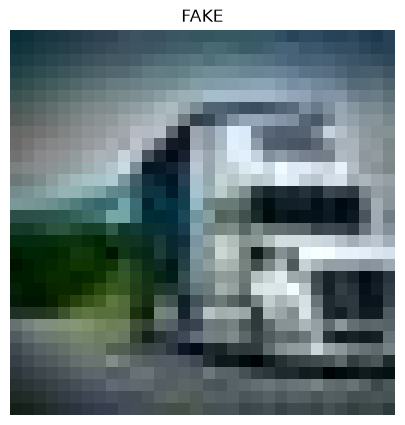

In [9]:
import matplotlib.pyplot as plt

sample = test_dataset[0]

print("Label:", sample["label"])
print("Label name:", test_dataset.features["label"].names[sample["label"]])

plt.figure(figsize=(5, 5))
plt.imshow(sample["image"])
plt.axis("off")
plt.title(
    test_dataset.features["label"].names[sample["label"]]
)

plt.show()

In [10]:
from torch.utils.data import Dataset, DataLoader


class CIFAKETestDataset(Dataset):

    def __init__(self, hf_dataset, transform):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        image = item["image"].convert("RGB")
        label = item["label"]

        image = self.transform(image)

        return image, label


test_dataset_torch = CIFAKETestDataset(
    test_dataset,
    transform
)


test_loader = DataLoader(
    test_dataset_torch,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test DataLoader ready")
print("Test samples:", len(test_dataset_torch))
print("Test batches:", len(test_loader))

Test DataLoader ready
Test samples: 20000
Test batches: 625


In [11]:
import torch

all_labels = []
all_predictions = []
all_probabilities = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        predictions = torch.argmax(probabilities, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

        # Probability of REAL (class 1)
        all_probabilities.extend(
            probabilities[:, 1].cpu().numpy()
        )

print("Inference complete")
print("Total predictions:", len(all_predictions))

Inference complete
Total predictions: 20000


In [12]:
print("Labels:", len(all_labels))
print("Predictions:", len(all_predictions))
print("Probabilities:", len(all_probabilities))

print("\nFirst 10 predictions:")
print(all_predictions[:10])

print("\nFirst 10 probabilities:")
print(all_probabilities[:10])

Labels: 20000
Predictions: 20000
Probabilities: 20000

First 10 predictions:
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]

First 10 probabilities:
[np.float32(1.7123553e-05), np.float32(0.012192742), np.float32(0.00088369433), np.float32(7.916478e-06), np.float32(0.00051159423), np.float32(4.8409493e-05), np.float32(0.00014171332), np.float32(4.064234e-08), np.float32(4.4700099e-07), np.float32(1.7471773e-05)]


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
roc_auc = roc_auc_score(all_labels, all_probabilities)
cm = confusion_matrix(all_labels, all_predictions)

print("=" * 60)
print("DEEPSHIELD-AI — FINAL PHOTO MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["FAKE", "REAL"],
        digits=4
    )
)

print("\nConfusion Matrix:")
print(cm)

DEEPSHIELD-AI — FINAL PHOTO MODEL EVALUATION
Accuracy  : 0.9784 (97.84%)
Precision : 0.9833
Recall    : 0.9732
F1 Score  : 0.9782
ROC-AUC   : 0.9976

Classification Report:
              precision    recall  f1-score   support

        FAKE     0.9735    0.9835    0.9785     10000
        REAL     0.9833    0.9732    0.9782     10000

    accuracy                         0.9784     20000
   macro avg     0.9784    0.9784    0.9783     20000
weighted avg     0.9784    0.9784    0.9783     20000


Confusion Matrix:
[[9835  165]
 [ 268 9732]]


In [14]:
import json
import os

os.makedirs("../models", exist_ok=True)

photo_metrics = {
    "model": "ResNet18",
    "task": "Photo Authenticity Detection",
    "test_samples": len(all_labels),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc),
    "confusion_matrix": cm.tolist()
}

with open("../models/photo_metrics.json", "w") as f:
    json.dump(photo_metrics, f, indent=4)

print("Photo metrics saved:")
print("../models/photo_metrics.json")

Photo metrics saved:
../models/photo_metrics.json


In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# --------------------------------------------------
# Select test image
# --------------------------------------------------

sample_index = 0

sample = test_dataset[sample_index]

image = sample["image"].convert("RGB")
true_label = sample["label"]

# Apply the same preprocessing used by the model
input_tensor = transform(image).unsqueeze(0).to(DEVICE)


# --------------------------------------------------
# Model prediction
# --------------------------------------------------

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)

predicted_class = torch.argmax(probabilities, dim=1).item()
confidence = probabilities[0, predicted_class].item()

label_names = ["FAKE", "REAL"]

print("True label     :", label_names[true_label])
print("Predicted label:", label_names[predicted_class])
print("Confidence     :", f"{confidence * 100:.2f}%")

True label     : FAKE
Predicted label: FAKE
Confidence     : 100.00%


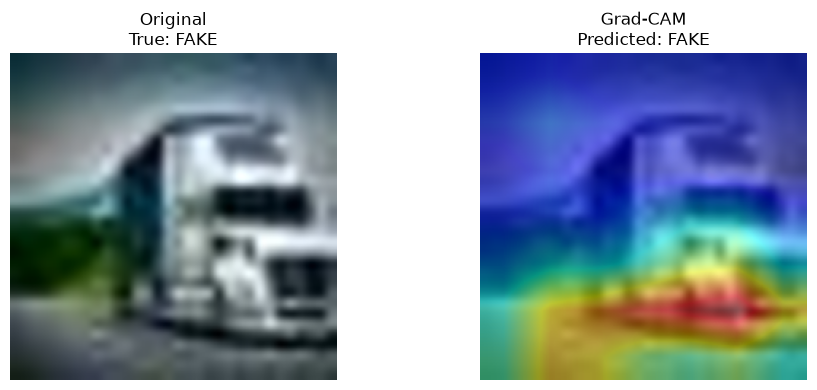

In [16]:
# --------------------------------------------------
# Grad-CAM
# --------------------------------------------------

target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

targets = [
    ClassifierOutputTarget(predicted_class)
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]


# --------------------------------------------------
# Prepare image for visualization
# --------------------------------------------------

rgb_image = np.array(image.resize((224, 224))).astype(np.float32) / 255.0

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)


# --------------------------------------------------
# Display
# --------------------------------------------------

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title(
    f"Original\nTrue: {label_names[true_label]}"
)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(
    f"Grad-CAM\nPredicted: {label_names[predicted_class]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
def explain_photo(sample_index):
    """
    Generate prediction + Grad-CAM explanation
    for any image in the test dataset.
    """

    sample = test_dataset[sample_index]

    image = sample["image"].convert("RGB")
    true_label = sample["label"]

    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    # -----------------------------
    # Prediction
    # -----------------------------
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

    predicted_class = torch.argmax(
        probabilities, dim=1
    ).item()

    confidence = probabilities[
        0, predicted_class
    ].item()

    label_names = ["FAKE", "REAL"]

    # -----------------------------
    # Grad-CAM
    # -----------------------------
    target_layers = [model.layer4[-1]]

    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    targets = [
        ClassifierOutputTarget(predicted_class)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # -----------------------------
    # Visualization
    # -----------------------------
    rgb_image = np.array(
        image.resize((224, 224))
    ).astype(np.float32) / 255.0

    visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    # -----------------------------
    # Display
    # -----------------------------
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_image)
    plt.title(
        f"Original\n"
        f"True: {label_names[true_label]}"
    )
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(
        f"Grad-CAM\n"
        f"Predicted: {label_names[predicted_class]} "
        f"({confidence * 100:.2f}%)"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "true_label": label_names[true_label],
        "predicted_label": label_names[predicted_class],
        "confidence": confidence
    }

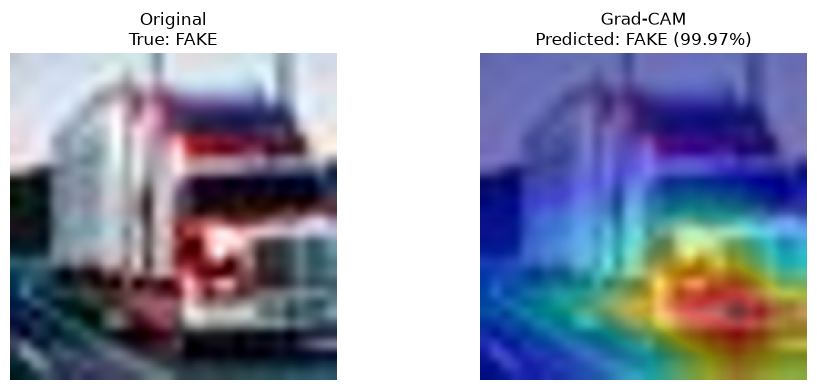


Result:
{'true_label': 'FAKE', 'predicted_label': 'FAKE', 'confidence': 0.9997486472129822}


In [19]:
result = explain_photo(100)

print("\nResult:")
print(result)

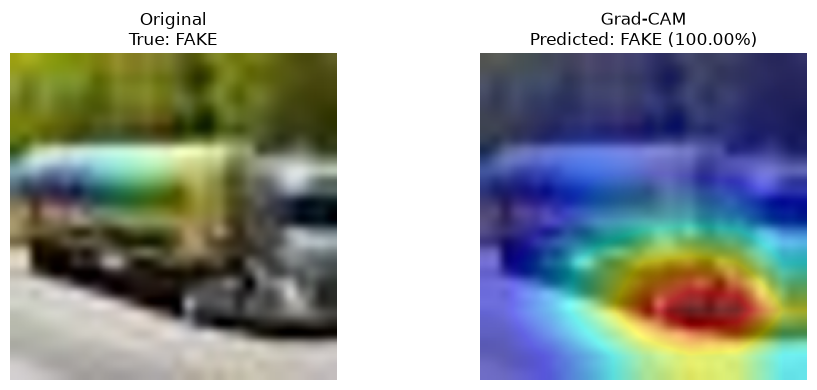

In [20]:
result = explain_photo(5000)

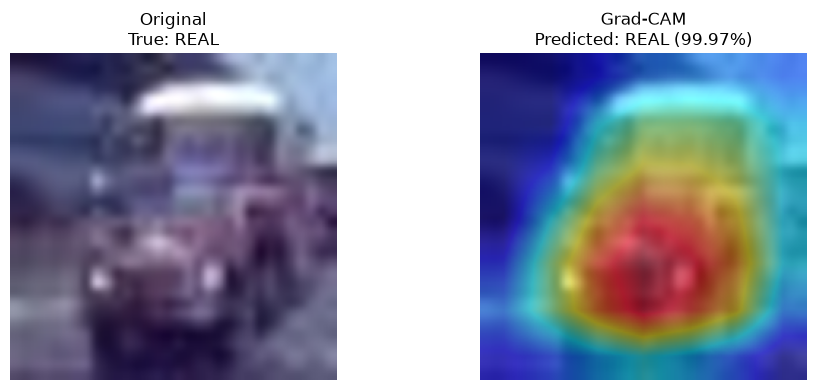

In [21]:
result = explain_photo(15000)